# Baseline & Agentic RAG Exploratory Data Analysis

Covers all three evaluation datasets:
- `agentic_rag_20 comparison questions.csv` - 20 agentic queries with full metadata
- `baseline_rag_20 comparison questions.csv` - 20 baseline queries (same questions)
- `agentic_rag_60 questions.csv` - 60-question full agentic evaluation

**Sections**
1. Query-Type & Scope Distribution
2. Response Time Analysis
3. Cost & Token Analysis
4. Confidence Analysis
5. Correlation Heatmaps
6. Per-Query Cost, Latency & Confidence Profiles

In [154]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

EVALS_DIR    = Path(".")
DATASETS_DIR = EVALS_DIR / "datasets"

OOS_MARKER = "outside the German timber market scope"

COLORS     = ["#2563EB", "#10B981", "#7C3AED", "#F97316"]
AGT_COLOR  = "#2563EB"
BASE_COLOR = "#F97316"
TYPE_COLORS = {"simple": "#2563EB", "temporal": "#10B981",
               "multi_hop": "#7C3AED", "comparison": "#F97316",
               "requires_live_search": "#F59E0B"}

plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "#F8F9FA",
    "axes.edgecolor":     "#D1D5DB",
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.titlesize":     13,
    "axes.titleweight":   "bold",
    "axes.titlepad":      12,
    "axes.labelsize":     11,
    "axes.labelcolor":    "#374151",
    "axes.axisbelow":     True,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "xtick.color":        "#6B7280",
    "ytick.color":        "#6B7280",
    "xtick.bottom":       False,
    "ytick.left":         False,
    "grid.color":         "#E5E7EB",
    "grid.linewidth":     0.75,
    "grid.linestyle":     "--",
    "legend.fontsize":    10,
    "legend.framealpha":  0.95,
    "legend.edgecolor":   "#E5E7EB",
    "figure.dpi":         130,
    "savefig.bbox":       "tight",
})

def _style(ax, ylabel=None, ylim=None):
    ax.spines["left"].set_color("#D1D5DB")
    ax.spines["bottom"].set_color("#D1D5DB")
    ax.yaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)
    if ylabel: ax.set_ylabel(ylabel, labelpad=8)
    if ylim:   ax.set_ylim(*ylim)

# Load datasets
agt20 = pd.read_csv(DATASETS_DIR / "agentic_rag_20 comparison questions.csv", encoding="utf-8-sig")
bas20 = pd.read_csv(DATASETS_DIR / "baseline_rag_20 comparison questions.csv", encoding="latin-1")
agt60 = pd.read_csv(DATASETS_DIR / "agentic_rag_60 questions.csv", encoding="utf-8-sig")

for df in [agt20, bas20, agt60]:
    df.columns = [c.lstrip("\ufeff").strip() for c in df.columns]
    df.rename(columns={c: "No." for c in df.columns if c.endswith("No.")}, inplace=True)

def _parse_conf(s):
    s = str(s).strip()
    if "%" in s:
        return float(s.replace("%", "")) / 100
    try:    return float(s)
    except: return np.nan

for df in [agt20, bas20, agt60]:
    df["confidence"] = df["Confidence / Avg Similarity"].apply(_parse_conf)
    for col in ["Cost ($)", "Tokens", "LLM Calls", "Resp. Time (s)"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df["query_len"]    = df["Query"].str.split().str.len()
    df["response_len"] = df["Response"].str.split().str.len()
    ctx_cols = [c for c in df.columns if re.match(r"context_\d+", c)]
    df["ctx_count"] = df[ctx_cols].apply(
        lambda r: r.fillna("").astype(str).str.strip().ne("").sum(), axis=1)

# Scope labelling for 60q
agt60["scope"] = agt60.apply(
    lambda row: "OOS" if OOS_MARKER in str(row["ground_truth"]) else (
                "Live" if row["query_type"] == "requires_live_search" else "In-scope"), axis=1)

agt60_in = agt60[agt60["scope"] == "In-scope"].copy()

print(f"agt20 : {agt20.shape}")
print(f"bas20 : {bas20.shape}")
print(f"agt60 : {agt60.shape}")
print(f"  scope breakdown: { dict(agt60['scope'].value_counts()) }")
print(f"  in-scope rows  : {len(agt60_in)}")
print("Setup complete.")


agt20 : (20, 25)
bas20 : (20, 21)
agt60 : (60, 26)
  scope breakdown: {'In-scope': np.int64(46), 'Live': np.int64(8), 'OOS': np.int64(6)}
  in-scope rows  : 46
Setup complete.


## 1. Query-Type & Scope Distribution

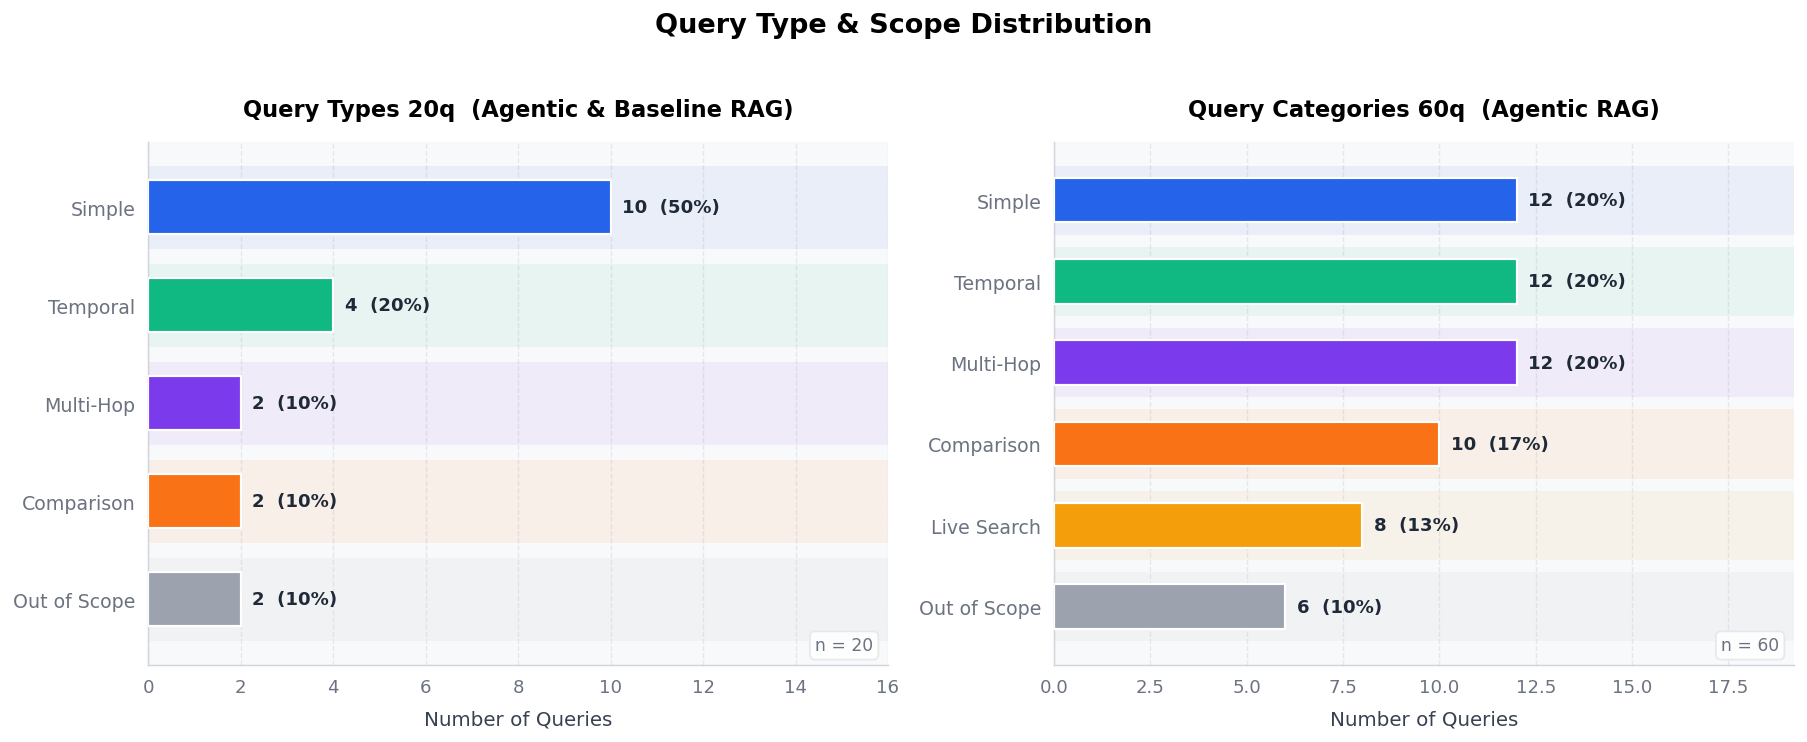

20q query types: {'Simple': np.int64(10), 'Temporal': np.int64(4), 'Multi-Hop': np.int64(2), 'Comparison': np.int64(2), 'Out of Scope': np.int64(2)}
60q breakdown  : {'Simple': np.int64(12), 'Temporal': np.int64(12), 'Multi-Hop': np.int64(12), 'Comparison': np.int64(10), 'Live Search': 8, 'Out of Scope': 6}


In [ ]:
# 20q: include all query_type values
all_types_20  = agt20["query_type"].value_counts()
cat_order_20  = ["simple", "temporal", "multi_hop", "comparison", "Out_of_Scope"]
counts_20     = all_types_20.reindex(cat_order_20).fillna(0).astype(int)
colors_20     = ["#2563EB", "#10B981", "#7C3AED", "#F97316", "#9CA3AF"]
labels_20     = ["Simple", "Temporal", "Multi-Hop", "Comparison", "Out of Scope"]

# 60q categories
type_counts_60 = agt60_in["query_type"].value_counts().reindex(
    ["simple", "temporal", "multi_hop", "comparison"]).fillna(0).astype(int)
live_count = int((agt60["scope"] == "Live").sum())
oos_count  = int((agt60["scope"] == "OOS").sum())

cat_labels_60 = ["Simple", "Temporal", "Multi-Hop", "Comparison", "Live Search", "Out of Scope"]
all_vals_60   = list(type_counts_60.values) + [live_count, oos_count]
cat_colors_60 = ["#2563EB", "#10B981", "#7C3AED", "#F97316", "#F59E0B", "#9CA3AF"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, (labels, values, colors, title, total) in zip(axes, [
    (labels_20, list(counts_20.values), colors_20,
     "Query Types 20q  (Agentic & Baseline RAG)", int(sum(counts_20.values))),
    (cat_labels_60, all_vals_60, cat_colors_60,
     "Query Categories 60q  (Agentic RAG)", int(sum(all_vals_60))),
]):
    max_v = max(values)
    # subtle background strips
    for j, (val, col) in enumerate(zip(values, colors)):
        ax.barh(j, max_v * 1.6, left=0, height=0.85, color=col, alpha=0.07, zorder=1)

    bars = ax.barh(range(len(labels)), values, color=colors,
                   edgecolor="white", linewidth=1.2, zorder=3, height=0.55)

    for bar, val in zip(bars, values):
        ax.text(val + max_v * 0.025, bar.get_y() + bar.get_height() / 2,
                f"{val}  ({val / total * 100:.0f}%)",
                va="center", ha="left", fontsize=10, fontweight="600", color="#1F2937")

    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=10.5)
    ax.set_xlim(0, max_v * 1.6)
    ax.set_title(title, fontsize=12.5, fontweight="bold", pad=14)
    ax.set_xlabel("Number of Queries", labelpad=8)
    ax.xaxis.grid(True, linestyle="--", color="#E5E7EB", linewidth=0.75, zorder=0)
    ax.yaxis.grid(False)
    ax.spines["left"].set_color("#D1D5DB");  ax.spines["bottom"].set_color("#D1D5DB")
    ax.spines["top"].set_visible(False);     ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True);  ax.set_facecolor("#F8F9FA")
    ax.invert_yaxis()
    ax.text(0.98, 0.02, f"n = {total}", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=9.5, color="#6B7280",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="#E5E7EB", alpha=0.9))

fig.suptitle("Query Type & Scope Distribution", fontsize=15, fontweight="bold", y=1.03)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

print("20q query types:", dict(zip(labels_20, counts_20.values)))
print("60q breakdown  :", dict(zip(cat_labels_60, all_vals_60)))


## 2. Response Time Analysis

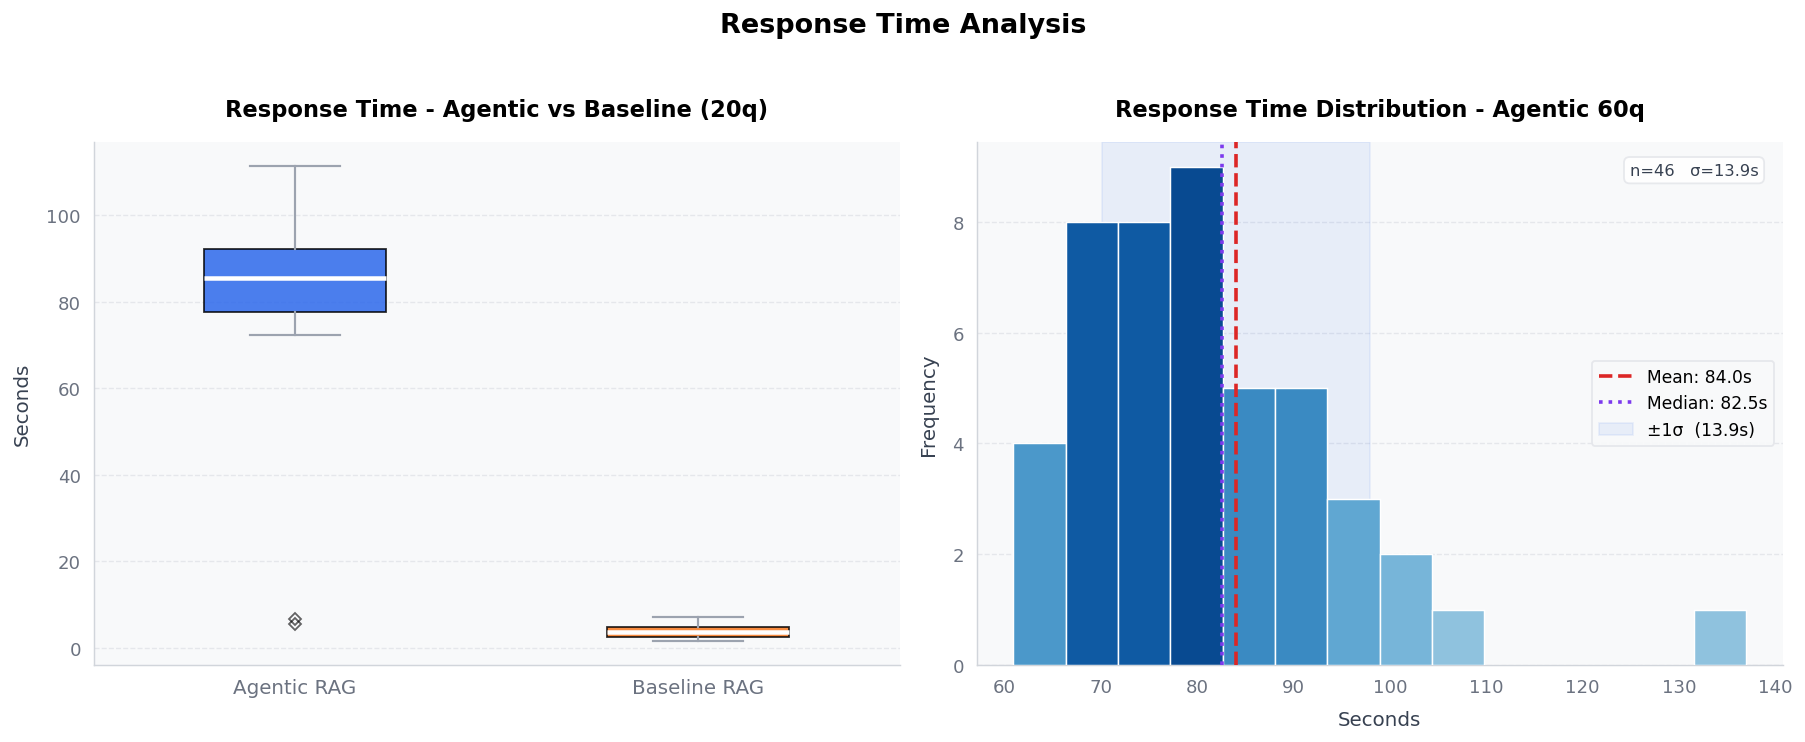

Agentic 20q  mean: 79.7s   median: 85.5s
Baseline 20q mean: 3.8s   median: 3.6s
Agentic 60q  mean: 84.0s


In [157]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: clean box plot - Agentic vs Baseline 20q 
ax = axes[0]
agt_rt = agt20["Resp. Time (s)"].dropna().values
bas_rt = bas20["Resp. Time (s)"].dropna().values

bp = ax.boxplot([agt_rt, bas_rt], positions=[1, 2], widths=0.45, patch_artist=True,
                medianprops=dict(color="white", linewidth=2.5),
                whiskerprops=dict(color="#9CA3AF", linewidth=1.2),
                capprops=dict(color="#9CA3AF", linewidth=1.2),
                flierprops=dict(marker="D", color="#9CA3AF", markersize=5, alpha=0.6))
for patch, color in zip(bp["boxes"], [AGT_COLOR, BASE_COLOR]):
    patch.set_facecolor(color); patch.set_alpha(0.82)

ax.set_xticks([1, 2])
ax.set_xticklabels(["Agentic RAG", "Baseline RAG"], fontsize=11)
ax.set_title("Response Time - Agentic vs Baseline (20q)", fontsize=12.5, fontweight="bold", pad=14)
ax.set_ylabel("Seconds", labelpad=8)
ax.yaxis.grid(True, linestyle="--", color="#E5E7EB", linewidth=0.75, zorder=0)
ax.set_axisbelow(True); ax.set_facecolor("#F8F9FA")
ax.spines["top"].set_visible(False);    ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D1D5DB"); ax.spines["bottom"].set_color("#D1D5DB")

# Right: gradient histogram + stats - Agentic 60q 
ax = axes[1]
rt_data  = agt60_in["Resp. Time (s)"].dropna()
n_bins   = 14
counts_h, edges = np.histogram(rt_data, bins=n_bins)
cmap_b   = plt.cm.Blues
norm_v   = counts_h / counts_h.max()
for j in range(n_bins):
    ax.bar(edges[j], counts_h[j], width=edges[j+1] - edges[j],
           color=cmap_b(0.35 + 0.55 * norm_v[j]),
           edgecolor="white", linewidth=0.8, zorder=3)

mean_v   = rt_data.mean()
median_v = rt_data.median()
std_v    = rt_data.std()
ax.axvline(mean_v,   color="#DC2626", linestyle="--", linewidth=2.0, zorder=4,
           label=f"Mean: {mean_v:.1f}s")
ax.axvline(median_v, color="#7C3AED", linestyle=":",  linewidth=2.0, zorder=4,
           label=f"Median: {median_v:.1f}s")
ax.axvspan(mean_v - std_v, mean_v + std_v, alpha=0.08, color="#2563EB", zorder=1,
           label=f"±1σ  ({std_v:.1f}s)")

ax.set_title("Response Time Distribution - Agentic 60q", fontsize=12.5, fontweight="bold", pad=14)
ax.set_xlabel("Seconds", labelpad=8)
ax.set_ylabel("Frequency", labelpad=8)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#E5E7EB", fontsize=9.5)
_style(ax); ax.set_facecolor("#F8F9FA")
ax.text(0.97, 0.96, f"n={len(rt_data)}   σ={std_v:.1f}s",
        transform=ax.transAxes, ha="right", va="top", fontsize=9, color="#374151",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#E5E7EB", alpha=0.9))

fig.suptitle("Response Time Analysis", fontsize=15, fontweight="bold", y=1.03)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

print(f"Agentic 20q  mean: {agt20['Resp. Time (s)'].mean():.1f}s   median: {np.median(agt_rt):.1f}s")
print(f"Baseline 20q mean: {bas20['Resp. Time (s)'].mean():.1f}s   median: {np.median(bas_rt):.1f}s")
print(f"Agentic 60q  mean: {agt60_in['Resp. Time (s)'].mean():.1f}s")


## 3. Cost & Token Analysis

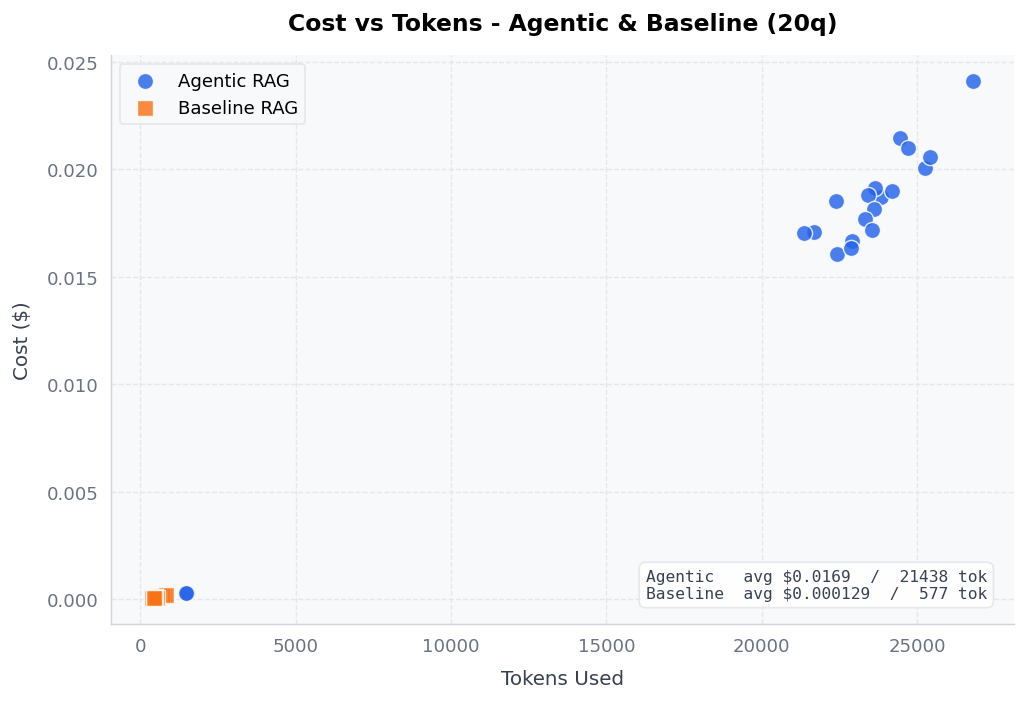

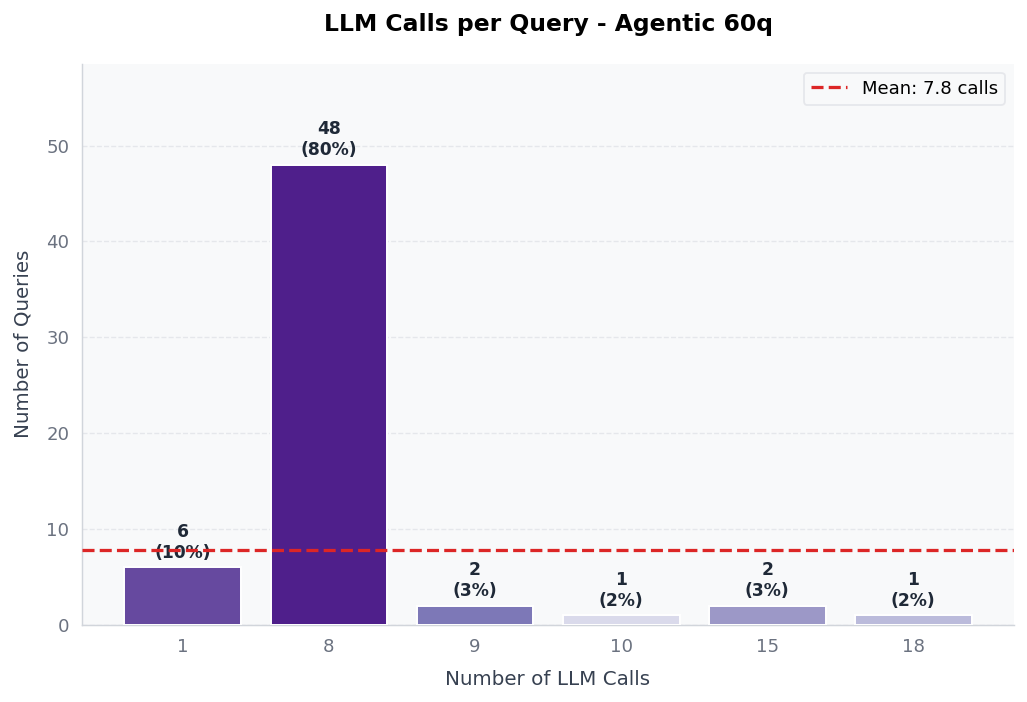

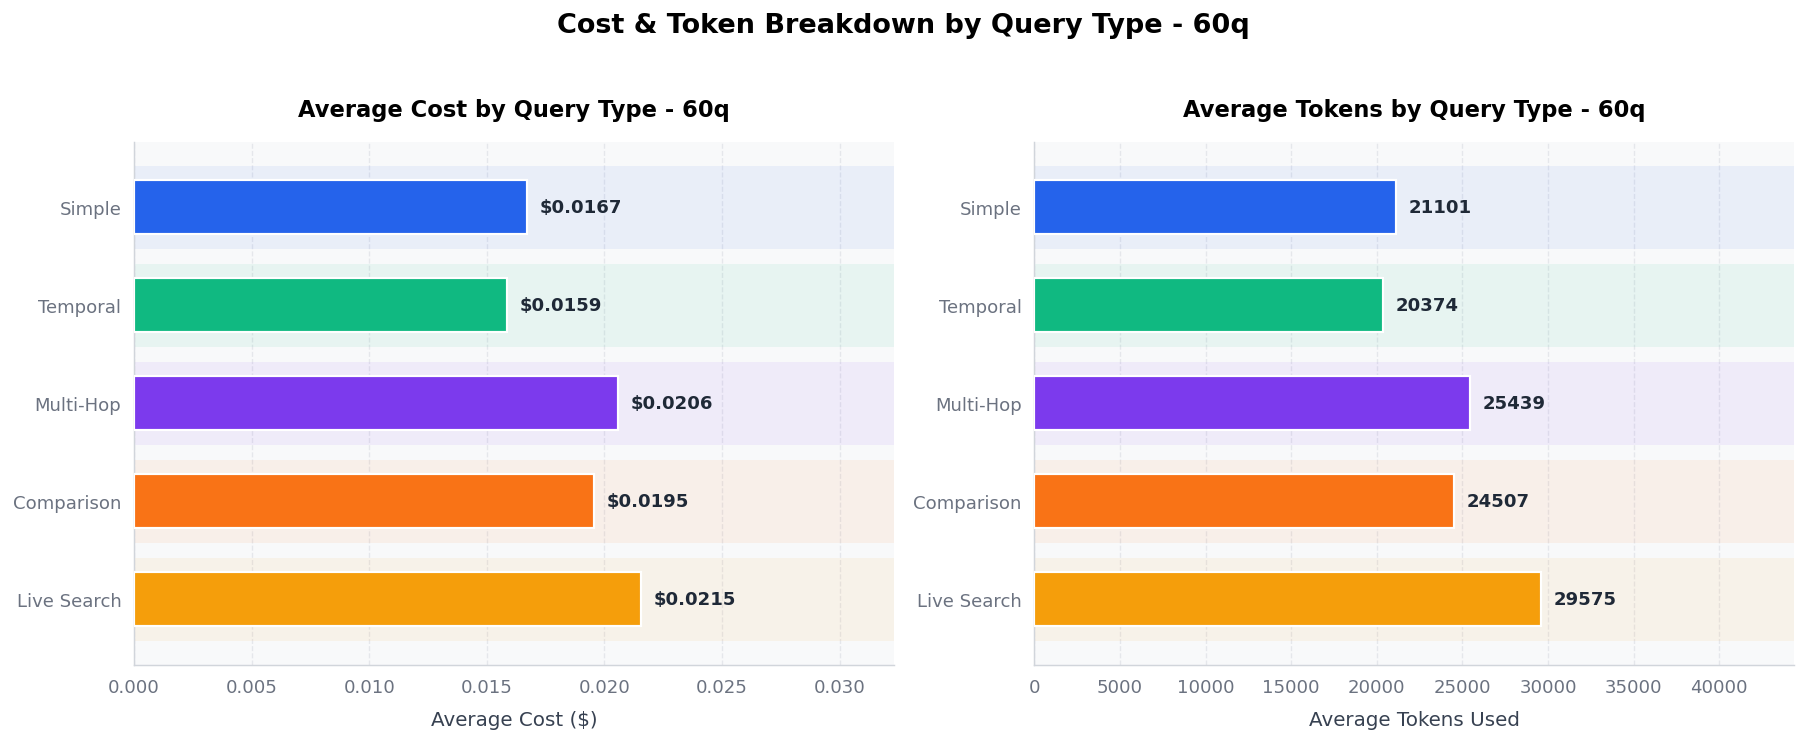

Agentic 20q  avg cost: $0.0169  avg tokens: 21438  avg LLM calls: 7.3
Baseline 20q avg cost: $0.000129  avg tokens: 577  avg LLM calls: 1.0

LLM calls distribution (all 60q):
LLM Calls
1      6
8     48
9      2
10     1
15     2
18     1
Name: count, dtype: int64


In [162]:

# Figure 1 - Cost vs Tokens  (Agentic & Baseline 20q)
fig, ax = plt.subplots(figsize=(8, 5.5))

for data, color, label, marker in [
    (agt20, AGT_COLOR,  "Agentic RAG",  "o"),
    (bas20, BASE_COLOR, "Baseline RAG", "s"),
]:
    ax.scatter(data["Tokens"], data["Cost ($)"],
               color=color, alpha=0.82, s=80, marker=marker,
               edgecolors="white", linewidths=0.8, label=label, zorder=3)

ax.set_title("Cost vs Tokens - Agentic & Baseline (20q)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Tokens Used", labelpad=8)
ax.set_ylabel("Cost ($)", labelpad=8)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#E5E7EB", fontsize=10)
_style(ax); ax.set_facecolor("#F8F9FA")
ax.xaxis.grid(True, linestyle="--", color="#E5E7EB", linewidth=0.75, zorder=0)

stats_box = (
    f"Agentic   avg ${agt20['Cost ($)'].mean():.4f}  /  {agt20['Tokens'].mean():.0f} tok\n"
    f"Baseline  avg ${bas20['Cost ($)'].mean():.6f}  /  {bas20['Tokens'].mean():.0f} tok"
)
ax.text(0.97, 0.04, stats_box, transform=ax.transAxes, ha="right", va="bottom",
        fontsize=9, color="#374151", family="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#E5E7EB", alpha=0.92))

fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

# Figure 2 - LLM Calls per Query  (Agentic 60q - all queries)
fig, ax = plt.subplots(figsize=(8, 5.5))

llm_counts = agt60["LLM Calls"].value_counts().sort_index()
n_bars     = len(llm_counts)
total_q    = len(agt60)
cmap_p     = plt.cm.Purples

# color by rank: highest bar = darkest, lowest bar = lightest
ranks = llm_counts.values.argsort().argsort()          # rank each bar by count
bar_colors_llm = [cmap_p(0.25 + 0.65 * r / max(n_bars - 1, 1)) for r in ranks]

bars = ax.bar(llm_counts.index.astype(str), llm_counts.values,
              color=bar_colors_llm, edgecolor="white", linewidth=1.1, zorder=3)
for bar in bars:
    v = int(bar.get_height())
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.6,
            f"{v}\n({v / total_q * 100:.0f}%)",
            ha="center", va="bottom", fontsize=9.5, fontweight="600", color="#1F2937")

mean_calls = agt60["LLM Calls"].mean()
ax.axhline(mean_calls, color="#DC2626", linestyle="--", linewidth=1.8, zorder=4,
           label=f"Mean: {mean_calls:.1f} calls")

ax.set_title("LLM Calls per Query - Agentic 60q", fontsize=13, fontweight="bold", pad=18)
ax.set_xlabel("Number of LLM Calls", labelpad=8)
ax.set_ylabel("Number of Queries", labelpad=8)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#E5E7EB", fontsize=10)
_style(ax); ax.set_facecolor("#F8F9FA")
ax.xaxis.grid(False)
# add top margin so label doesn't crowd the title
ax.set_ylim(0, llm_counts.max() * 1.22)

fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

# Figure 3 - Avg Cost & Avg Tokens by Query Type  (60q)
TYPE_ORDER  = ["simple", "temporal", "multi_hop", "comparison", "requires_live_search"]
TYPE_LABELS = ["Simple", "Temporal", "Multi-Hop", "Comparison", "Live Search"]
T_COLORS    = [COLORS[0], COLORS[1], COLORS[2], COLORS[3], "#F59E0B"]

cost_by_type = agt60.groupby("query_type")["Cost ($)"].mean().reindex(TYPE_ORDER)
tok_by_type  = agt60.groupby("query_type")["Tokens"].mean().reindex(TYPE_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, (vals, xlabel, fmt, title) in zip(axes, [
    (cost_by_type.values, "Average Cost ($)",    "${:.4f}", "Average Cost by Query Type - 60q"),
    (tok_by_type.values,  "Average Tokens Used", "{:.0f}",  "Average Tokens by Query Type - 60q"),
]):
    max_v = float(np.nanmax(vals))
    for j, col in enumerate(T_COLORS):
        ax.barh(j, max_v * 1.5, left=0, height=0.85, color=col, alpha=0.07, zorder=1)

    bars = ax.barh(TYPE_LABELS, vals, color=T_COLORS,
                   edgecolor="white", linewidth=1.2, zorder=3, height=0.55)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(v + max_v * 0.025, bar.get_y() + bar.get_height() / 2,
                    fmt.format(v), va="center", ha="left",
                    fontsize=10, fontweight="600", color="#1F2937")

    ax.set_xlim(0, max_v * 1.5)
    ax.set_title(title, fontsize=12.5, fontweight="bold", pad=14)
    ax.set_xlabel(xlabel, labelpad=8)
    ax.xaxis.grid(True, linestyle="--", color="#E5E7EB", linewidth=0.75, zorder=0)
    ax.yaxis.grid(False)
    ax.spines["left"].set_color("#D1D5DB");  ax.spines["bottom"].set_color("#D1D5DB")
    ax.spines["top"].set_visible(False);     ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True);  ax.set_facecolor("#F8F9FA")
    ax.invert_yaxis()

fig.suptitle("Cost & Token Breakdown by Query Type - 60q",
             fontsize=15, fontweight="bold", y=1.03)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

print(f"Agentic 20q  avg cost: ${agt20['Cost ($)'].mean():.4f}  avg tokens: {agt20['Tokens'].mean():.0f}  avg LLM calls: {agt20['LLM Calls'].mean():.1f}")
print(f"Baseline 20q avg cost: ${bas20['Cost ($)'].mean():.6f}  avg tokens: {bas20['Tokens'].mean():.0f}  avg LLM calls: {bas20['LLM Calls'].mean():.1f}")
print(f"\nLLM calls distribution (all 60q):\n{agt60['LLM Calls'].value_counts().sort_index()}")


## 4. Confidence Analysis

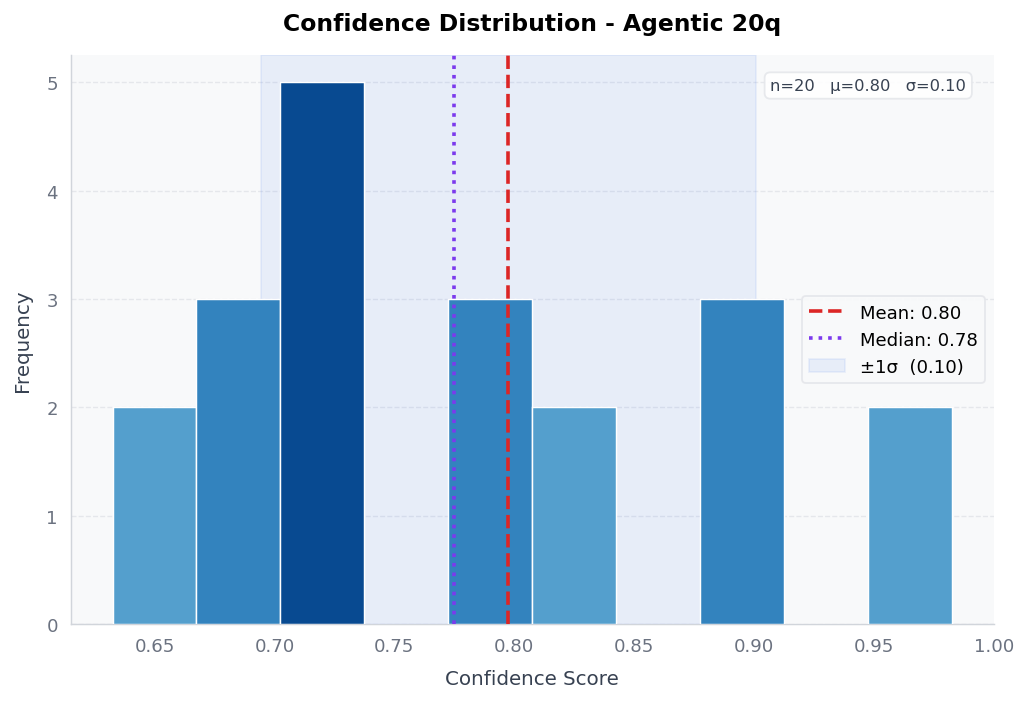

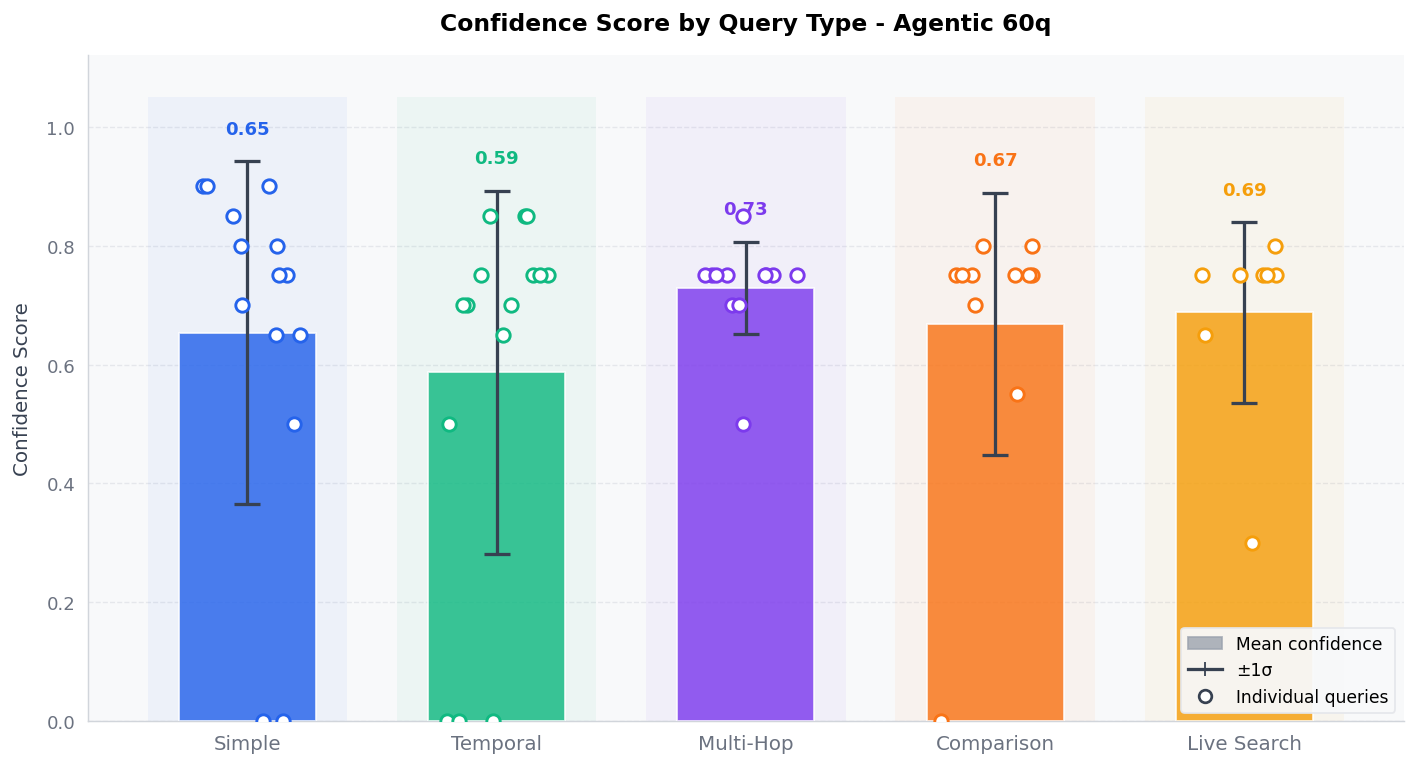

In [141]:
# Figure 1 - Confidence Distribution  (Agentic 20q)

fig, ax = plt.subplots(figsize=(8, 5.5))

conf_20  = agt20["confidence"].dropna()
n_bins   = 10
counts_h, edges = np.histogram(conf_20, bins=n_bins)
cmap_b   = plt.cm.Blues
norm_v   = counts_h / counts_h.max()
for j in range(n_bins):
    ax.bar(edges[j], counts_h[j], width=edges[j+1] - edges[j],
           color=cmap_b(0.35 + 0.55 * norm_v[j]),
           edgecolor="white", linewidth=0.8, zorder=3)

mean_c   = conf_20.mean()
median_c = conf_20.median()
ax.axvline(mean_c,   color="#DC2626", linestyle="--", linewidth=2.0, zorder=4,
           label=f"Mean: {mean_c:.2f}")
ax.axvline(median_c, color="#7C3AED", linestyle=":" , linewidth=2.0, zorder=4,
           label=f"Median: {median_c:.2f}")
ax.axvspan(mean_c - conf_20.std(), mean_c + conf_20.std(), alpha=0.08,
           color="#2563EB", zorder=1, label=f"±1σ  ({conf_20.std():.2f})")

ax.set_title("Confidence Distribution - Agentic 20q", fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Confidence Score", labelpad=8)
ax.set_ylabel("Frequency", labelpad=8)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#E5E7EB", fontsize=10)
_style(ax); ax.set_facecolor("#F8F9FA")
ax.text(0.97, 0.96,
        f"n={len(conf_20)}   μ={mean_c:.2f}   σ={conf_20.std():.2f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9, color="#374151",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#E5E7EB", alpha=0.9))

fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

# Figure 2 - Confidence by Query Type  (Agentic 60q)

import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(11, 6))

type_order  = ["simple", "temporal", "multi_hop", "comparison", "requires_live_search"]
type_labels = ["Simple", "Temporal", "Multi-Hop", "Comparison", "Live Search"]
box_colors  = [COLORS[0], COLORS[1], COLORS[2], COLORS[3], "#F59E0B"]
conf_lists  = [agt60[agt60["query_type"] == qt]["confidence"].dropna().values
               for qt in type_order]

rng   = np.random.default_rng(42)
xs    = np.arange(len(type_labels))
means = [v.mean() for v in conf_lists]
stds  = [v.std()  for v in conf_lists]

# subtle background stripe per group
for xi, col in zip(xs, box_colors):
    ax.bar(xi, 1.05, bottom=0, color=col, alpha=0.05, width=0.8, zorder=1)

# mean bars
ax.bar(xs, means, color=box_colors, width=0.55,
       edgecolor="white", linewidth=1.0, alpha=0.82, zorder=3)

# error bars
ax.errorbar(xs, means, yerr=stds,
            fmt="none", ecolor="#374151", elinewidth=1.8,
            capsize=7, capthick=1.8, zorder=4)

# individual jittered data points
for xi, vals, color in zip(xs, conf_lists, box_colors):
    jitter = rng.uniform(-0.22, 0.22, size=len(vals))
    ax.scatter(xi + jitter, vals,
               color="white", s=55, zorder=5,
               edgecolors=color, linewidths=1.6)

# mean value labels above each bar
for xi, mean_v, std_v, color in zip(xs, means, stds, box_colors):
    ax.text(xi, mean_v + std_v + 0.04, f"{mean_v:.2f}",
            ha="center", va="bottom", fontsize=10, fontweight="700", color=color)

ax.set_xticks(xs)
ax.set_xticklabels(type_labels, fontsize=11)
ax.set_title("Confidence Score by Query Type - Agentic 60q",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Confidence Score", labelpad=8)
ax.set_ylim(0, 1.12)
ax.yaxis.grid(True, linestyle="--", color="#E5E7EB", linewidth=0.75, zorder=0)
ax.set_axisbelow(True); ax.set_facecolor("#F8F9FA")
ax.spines["top"].set_visible(False);    ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D1D5DB"); ax.spines["bottom"].set_color("#D1D5DB")

bar_patch  = mpatches.Patch(color="#9CA3AF", alpha=0.8, label="Mean confidence")
err_line   = mlines.Line2D([], [], color="#374151", linewidth=1.8,
                            marker="|", markersize=8, label="±1σ")
dot_handle = mlines.Line2D([], [], linestyle="none", marker="o",
                             markerfacecolor="white", markeredgecolor="#374151",
                             markersize=7, markeredgewidth=1.5, label="Individual queries")
ax.legend(handles=[bar_patch, err_line, dot_handle],
          frameon=True, framealpha=0.95, edgecolor="#E5E7EB", fontsize=9.5,
          loc="lower right")

fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()


## 5. Correlation Heatmaps

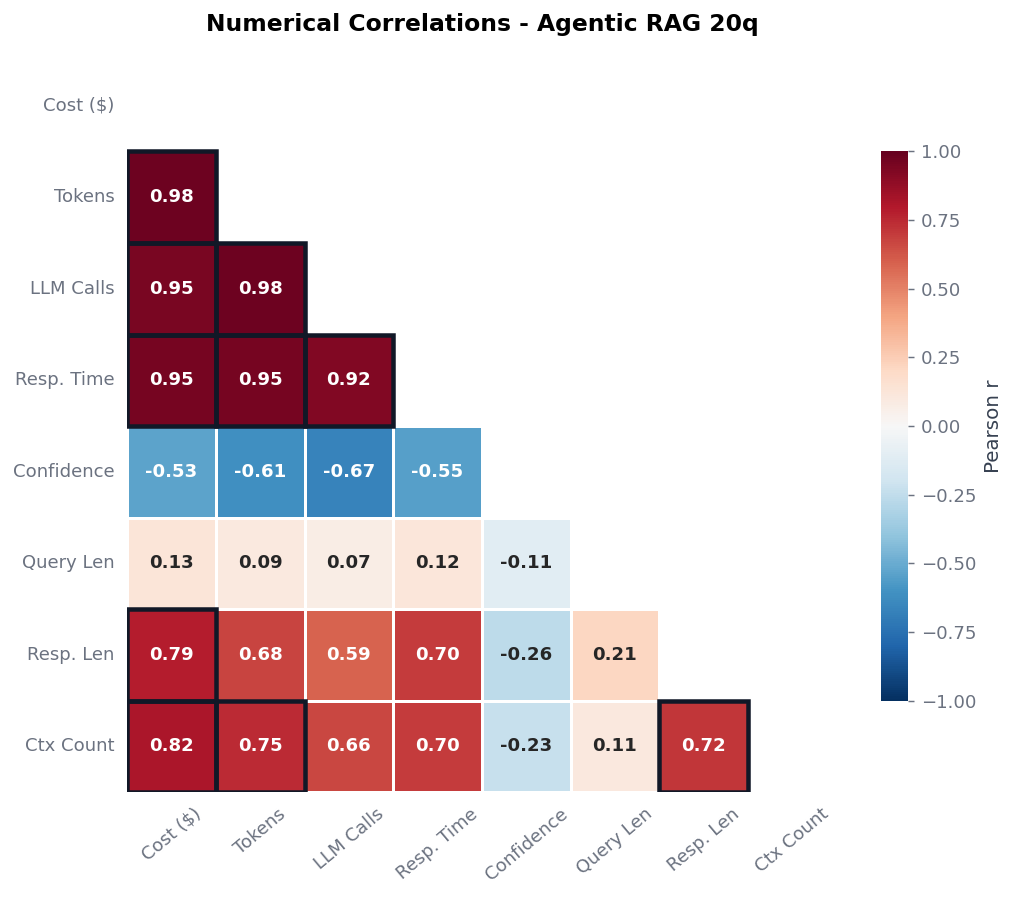

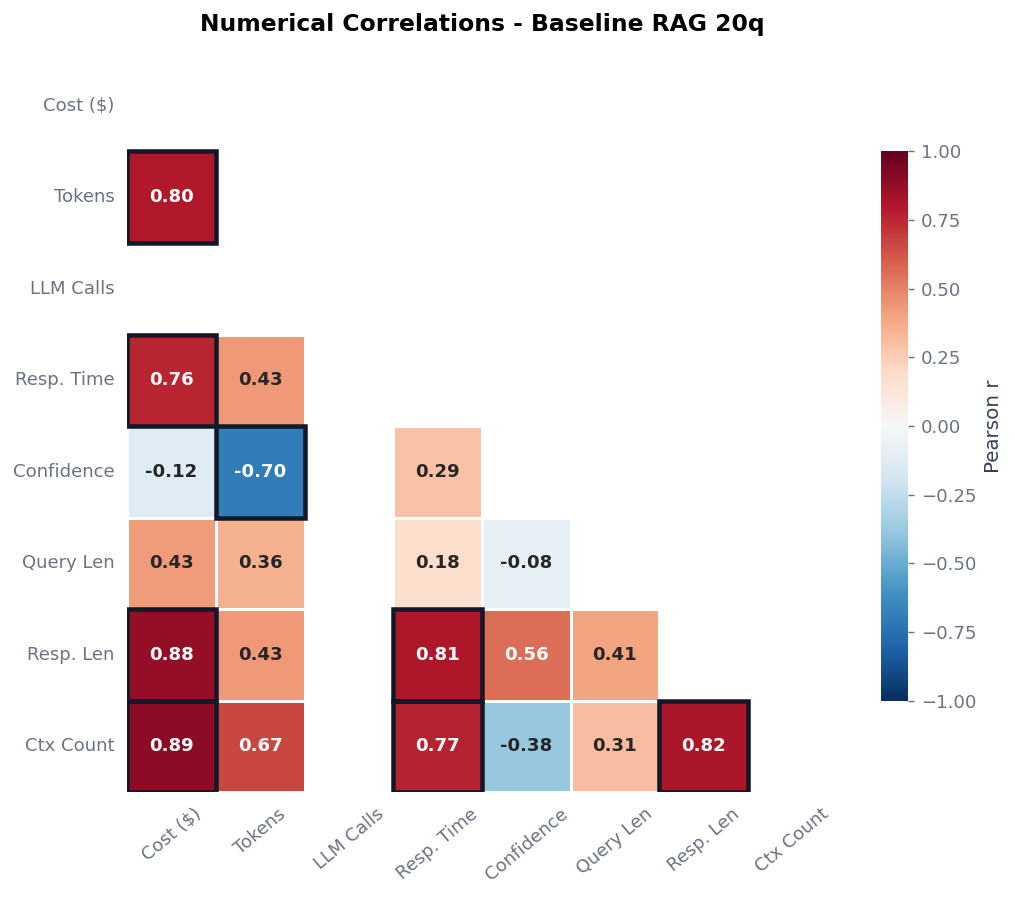

In [144]:

NUM_COLS  = ["Cost ($)", "Tokens", "LLM Calls", "Resp. Time (s)",
             "confidence", "query_len", "response_len", "ctx_count"]
LABEL_MAP = {
    "Cost ($)":       "Cost ($)",
    "Tokens":         "Tokens",
    "LLM Calls":      "LLM Calls",
    "Resp. Time (s)": "Resp. Time",
    "confidence":     "Confidence",
    "query_len":      "Query Len",
    "response_len":   "Resp. Len",
    "ctx_count":      "Ctx Count",
}

for dataset_title, df in [("Agentic RAG 20q", agt20), ("Baseline RAG 20q", bas20)]:
    sub  = df[[c for c in NUM_COLS if c in df.columns]].copy()
    sub.columns = [LABEL_MAP.get(c, c) for c in sub.columns]
    corr = sub.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(8, 7))

    sns.heatmap(corr, ax=ax, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                annot=True, fmt=".2f",
                annot_kws={"size": 10, "weight": "600"},
                linewidths=0.8, linecolor="white",
                cbar_kws={"shrink": 0.75, "label": "Pearson r"})

    # highlight strong correlations
    n = corr.shape[0]
    for i in range(n):
        for j in range(i):
            if abs(corr.iloc[i, j]) >= 0.7:
                ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                            edgecolor="#111827", lw=2.5, zorder=5))

    ax.set_title(f"Numerical Correlations - {dataset_title}",
                 fontsize=13, fontweight="bold", pad=16)
    ax.tick_params(axis="x", rotation=40, labelsize=10)
    ax.tick_params(axis="y", rotation=0,  labelsize=10)

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    plt.tight_layout()
    plt.show()


## 6. Per-Query Cost, Latency & Confidence Profiles

- **Plot 1** Dual-axis line: Cost $ + Response Time over every agentic query (60q)
- **Plot 2** Cost per query bar chart with cumulative line - Agentic vs Baseline (20q)
- **Plot 3** Response time bar chart per query, coloured by query type (60q in-scope)
- **Plot 4** Cost vs Confidence scatter - does higher spend correlate with better confidence?

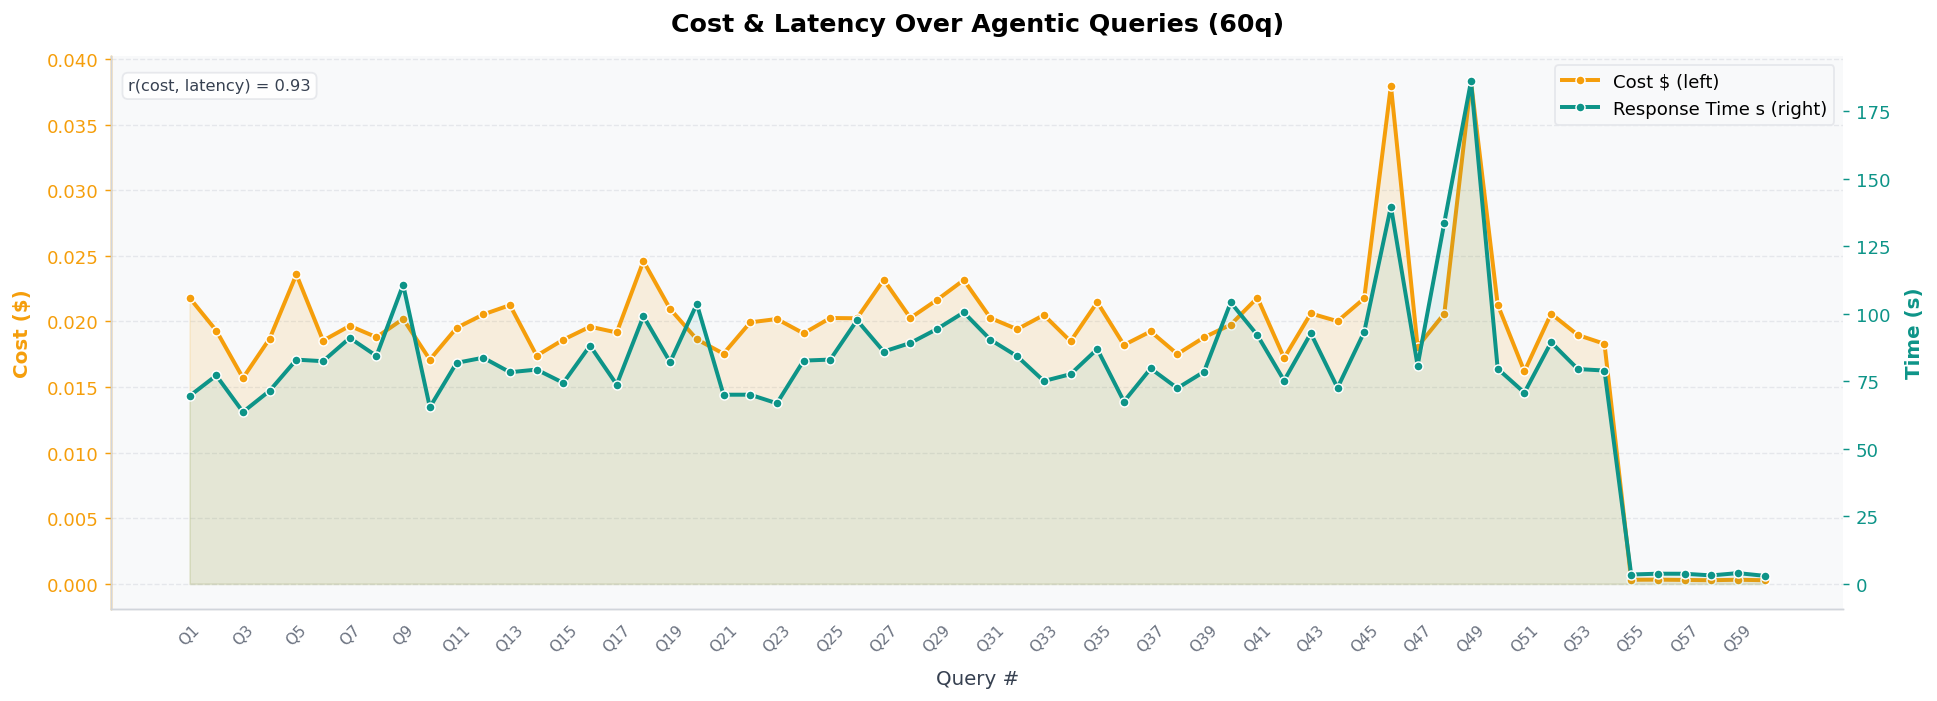

In [145]:

# Plot 1: Dual-axis, Cost & Latency over Agentic 60q
df_plot = agt60.reset_index(drop=True).copy()
df_plot["Q"] = ["Q" + str(i + 1) for i in df_plot.index]

color_cost = "#F59E0B"
color_time = "#0D9488"

fig, ax1 = plt.subplots(figsize=(15, 5.5))
fig.patch.set_facecolor("white")
ax1.set_facecolor("#F8F9FA")

lns1 = ax1.plot(df_plot["Q"], df_plot["Cost ($)"],
                color=color_cost, linewidth=2.2, marker="o", markersize=5,
                markerfacecolor=color_cost, markeredgecolor="white", markeredgewidth=0.8,
                label="Cost $ (left)", zorder=3)
ax1.fill_between(df_plot["Q"], df_plot["Cost ($)"],
                 alpha=0.12, color=color_cost, zorder=2)

ax1.set_ylabel("Cost ($)", color=color_cost, labelpad=8, fontweight="600")
ax1.tick_params(axis="y", colors=color_cost)
ax1.yaxis.grid(True, linestyle="--", color="#E5E7EB", linewidth=0.75, zorder=0)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_color(color_time)
ax1.spines["left"].set_color(color_cost)
ax1.spines["bottom"].set_color("#D1D5DB")

ax2 = ax1.twinx()
lns2 = ax2.plot(df_plot["Q"], df_plot["Resp. Time (s)"],
                color=color_time, linewidth=2.2, marker="o", markersize=5,
                markerfacecolor=color_time, markeredgecolor="white", markeredgewidth=0.8,
                label="Response Time s (right)", zorder=3)
ax2.fill_between(df_plot["Q"], df_plot["Resp. Time (s)"],
                 alpha=0.08, color=color_time, zorder=2)
ax2.set_ylabel("Time (s)", color=color_time, labelpad=8, fontweight="600")
ax2.tick_params(axis="y", colors=color_time)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_color(color_time)
ax2.set_facecolor("#F8F9FA")

for i, tick in enumerate(ax1.get_xticklabels()):
    tick.set_visible(i % 2 == 0)
ax1.tick_params(axis="x", rotation=45, labelsize=8.5, colors="#6B7280")

lns  = lns1 + lns2
ax1.legend(lns, [l.get_label() for l in lns], loc="upper right",
           frameon=True, framealpha=0.95, edgecolor="#E5E7EB", fontsize=10)

# stats annotation
corr_ct = df_plot[["Cost ($)", "Resp. Time (s)"]].dropna().corr().iloc[0, 1]
ax1.text(0.01, 0.96,
         f"r(cost, latency) = {corr_ct:.2f}",
         transform=ax1.transAxes, ha="left", va="top", fontsize=9, color="#374151",
         bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                   edgecolor="#E5E7EB", alpha=0.9))

ax1.set_title("Cost & Latency Over Agentic Queries (60q)",
              fontsize=14, fontweight="bold", pad=14)
ax1.set_xlabel("Query #", labelpad=8)
plt.tight_layout()
plt.show()


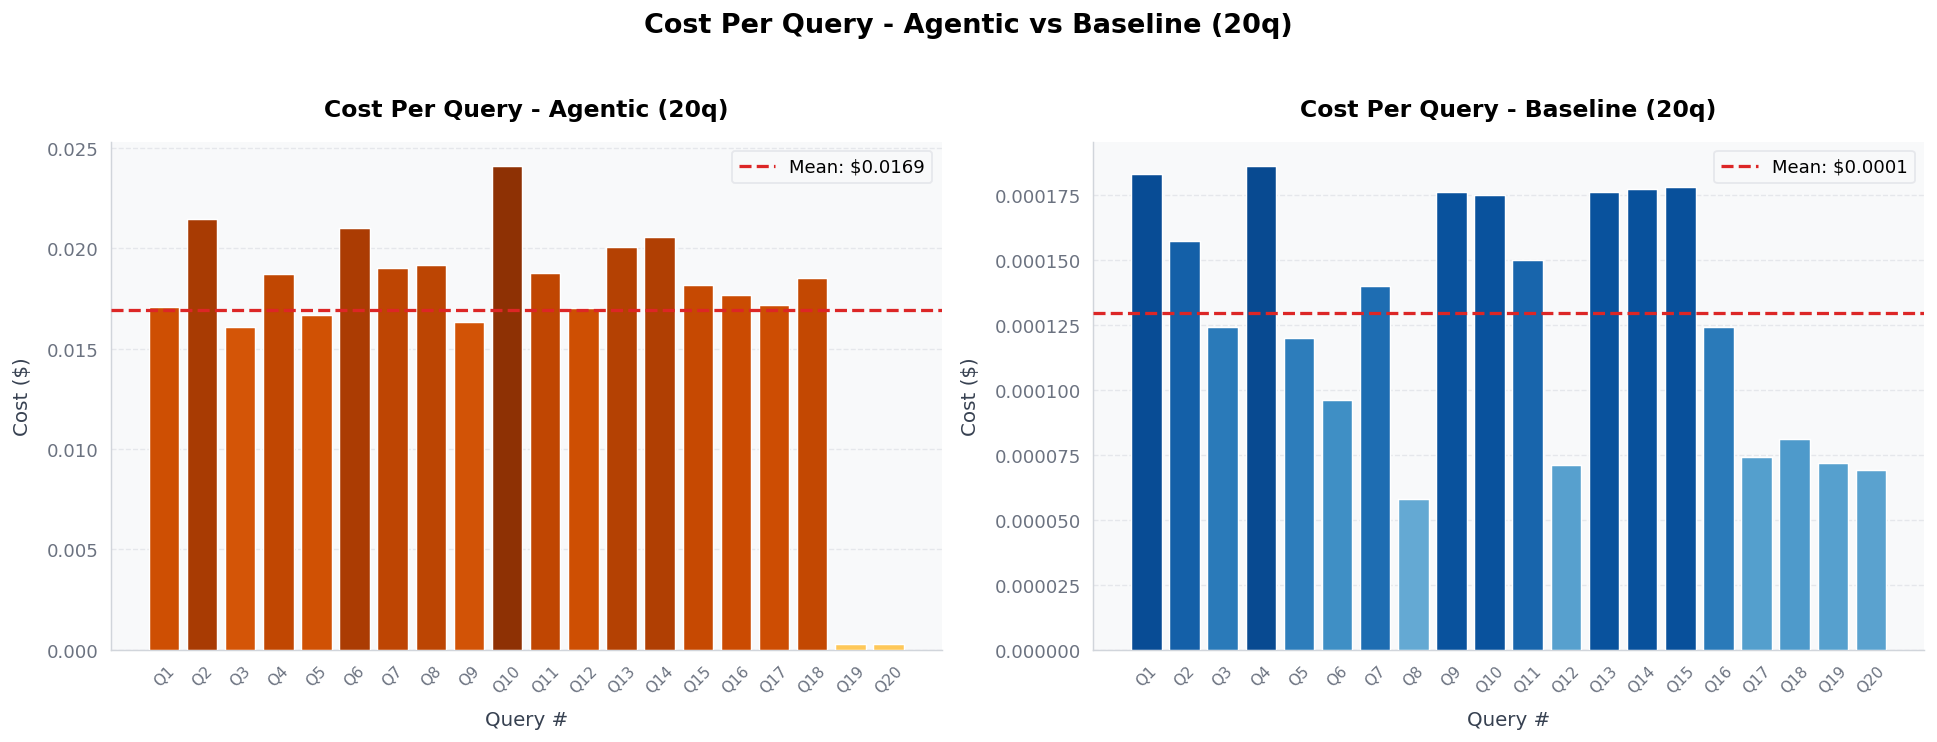

Total agentic cost  (20q): $0.3380
Total baseline cost (20q): $0.002587
Cost ratio: agentic is 131x more expensive


In [ ]:
# Plot 2: Cost per query - Agentic (left) & Baseline (right)
a20 = agt20.reset_index(drop=True).copy()
b20 = bas20.reset_index(drop=True).copy()
n       = min(len(a20), len(b20))
x       = np.arange(n)
xlabels = ["Q" + str(i + 1) for i in range(n)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for ax, data, color, label in [
    (axes[0], a20, "#F59E0B", "Agentic"),
    (axes[1], b20, "#2563EB", "Baseline"),
]:
    vals = data["Cost ($)"][:n].values
    norm_v = vals / vals.max()
    cmap_use = plt.cm.YlOrBr if color == "#F59E0B" else plt.cm.Blues

    for xi, (v, nv) in enumerate(zip(vals, norm_v)):
        ax.bar(xi, v, color=cmap_use(0.35 + 0.55 * nv),
               edgecolor="white", linewidth=0.8, zorder=3)

    mean_v = vals.mean()
    ax.axhline(mean_v, color="#DC2626", linestyle="--", linewidth=1.8, zorder=4,
               label=f"Mean: ${mean_v:.4f}")

    ax.set_title(f"Cost Per Query - {label} (20q)", fontsize=13, fontweight="bold", pad=14)
    ax.set_xlabel("Query #", labelpad=8)
    ax.set_ylabel("Cost ($)", labelpad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=45, fontsize=8.5, color="#6B7280")
    ax.legend(frameon=True, framealpha=0.95, edgecolor="#E5E7EB", fontsize=10)
    ax.yaxis.grid(True, linestyle="--", color="#E5E7EB", linewidth=0.75, zorder=0)
    ax.set_axisbelow(True);  ax.set_facecolor("#F8F9FA")
    ax.spines["top"].set_visible(False);   ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#D1D5DB"); ax.spines["bottom"].set_color("#D1D5DB")

fig.suptitle("Cost Per Query - Agentic vs Baseline (20q)",
             fontsize=15, fontweight="bold", y=1.03)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

print(f"Total agentic cost  (20q): ${a20['Cost ($)'].sum():.4f}")
print(f"Total baseline cost (20q): ${b20['Cost ($)'].sum():.6f}")
print(f"Cost ratio: agentic is {a20['Cost ($)'].sum() / b20['Cost ($)'].sum():.0f}x more expensive")


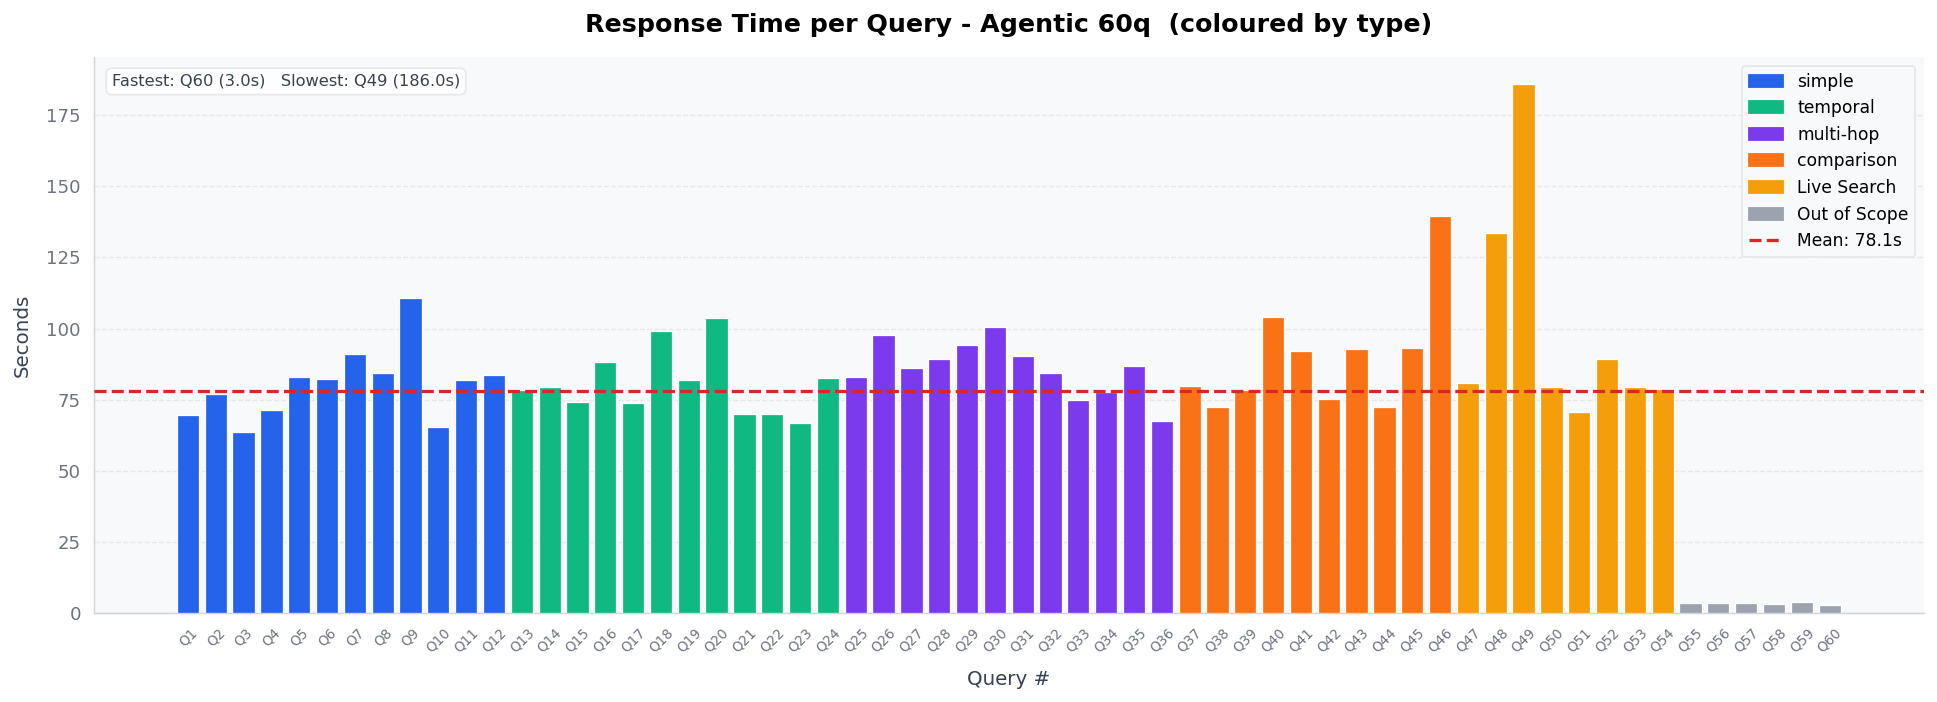

Fastest: Q60 (3.0s)Out of Scope
Slowest: Q49 (186.0s)Live Search
Std dev: 31.5s


In [153]:

# Plot 3: Response time bar chart - Agentic 60q, coloured by query type
df_rt = agt60.reset_index(drop=True).copy()
df_rt["Q"] = ["Q" + str(i + 1) for i in df_rt.index]
bar_colors_rt = [
    "#9CA3AF" if row["scope"] == "OOS"
    else TYPE_COLORS.get(row["query_type"], "#9CA3AF")
    for _, row in df_rt.iterrows()
]

fig, ax = plt.subplots(figsize=(15, 5.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F9FA")

ax.bar(df_rt["Q"], df_rt["Resp. Time (s)"],
       color=bar_colors_rt, edgecolor="white", linewidth=0.7, zorder=3)

mean_rt = df_rt["Resp. Time (s)"].mean()
ax.axhline(mean_rt, color="#DC2626", linestyle="--", linewidth=1.8,
           zorder=4, label=f"Mean: {mean_rt:.1f}s")

ax.set_title("Response Time per Query - Agentic 60q  (coloured by type)",
             fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Query #", labelpad=8)
ax.set_ylabel("Seconds", labelpad=8)
ax.tick_params(axis="x", rotation=45, labelsize=7.5, colors="#6B7280")
ax.yaxis.grid(True, linestyle="--", color="#E5E7EB", linewidth=0.75, zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False);    ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D1D5DB"); ax.spines["bottom"].set_color("#D1D5DB")

type_handles = [
    mpatches.Patch(color=c,
                   label=t.replace("_", "-").replace("requires-live-search", "Live Search"))
    for t, c in TYPE_COLORS.items()
]
oos_handle = mpatches.Patch(color="#9CA3AF", label="Out of Scope")
h_mean     = plt.Line2D([0], [0], color="#DC2626", linestyle="--",
                         linewidth=1.8, label=f"Mean: {mean_rt:.1f}s")
ax.legend(handles=type_handles + [oos_handle, h_mean], loc="upper right",
          frameon=True, framealpha=0.95, edgecolor="#E5E7EB", fontsize=9.5)

fastest = df_rt.loc[df_rt["Resp. Time (s)"].idxmin()]
slowest = df_rt.loc[df_rt["Resp. Time (s)"].idxmax()]
ax.text(0.01, 0.97,
        f"Fastest: {fastest['Q']} ({fastest['Resp. Time (s)']:.1f}s)   "
        f"Slowest: {slowest['Q']} ({slowest['Resp. Time (s)']:.1f}s)",
        transform=ax.transAxes, ha="left", va="top", fontsize=9, color="#374151",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                  edgecolor="#E5E7EB", alpha=0.9))

plt.tight_layout()
plt.show()

print(f"Fastest: {fastest['Q']} ({fastest['Resp. Time (s)']:.1f}s)"
      f"{'Out of Scope' if fastest['scope'] == 'OOS' else fastest['query_type'].replace('requires_live_search', 'Live Search')}")
print(f"Slowest: {slowest['Q']} ({slowest['Resp. Time (s)']:.1f}s)"
      f"{'Out of Scope' if slowest['scope'] == 'OOS' else slowest['query_type'].replace('requires_live_search', 'Live Search')}")
print(f"Std dev: {df_rt['Resp. Time (s)'].std():.1f}s")


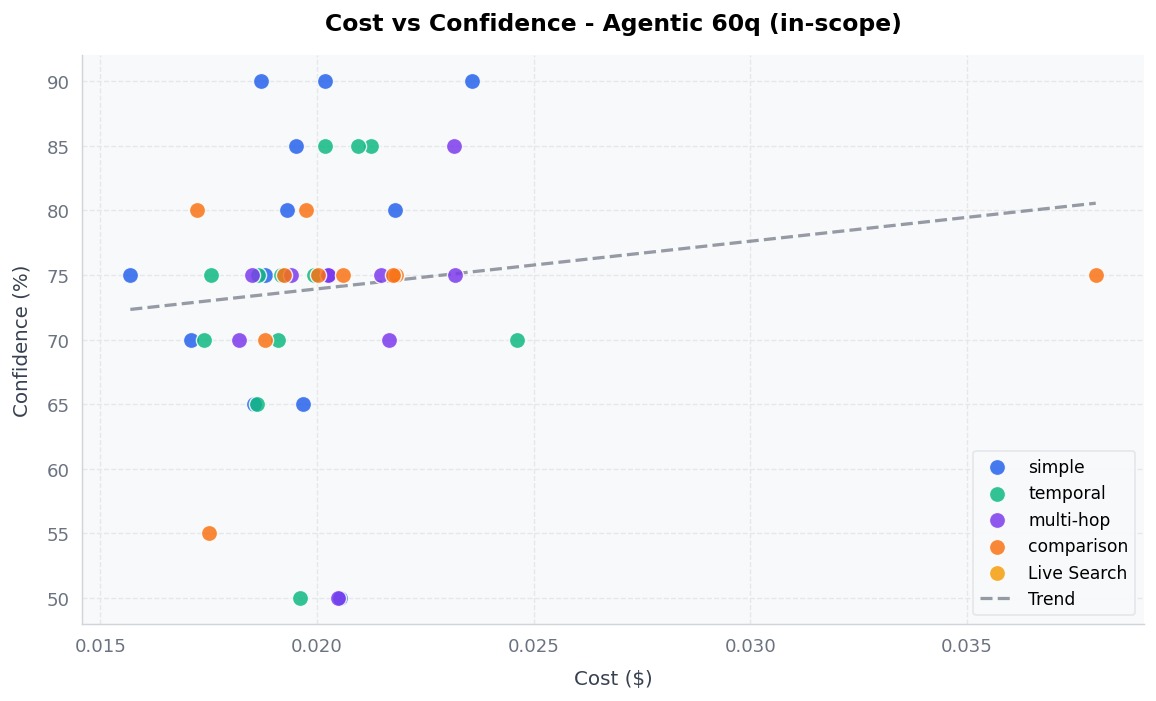

Pearson r (cost vs confidence) 60q: 0.126


In [ ]:

# Plot 4: Cost vs Confidence, Agentic 60q in-scope
fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F9FA")

for qt, color in TYPE_COLORS.items():
    sub = agt60_in[agt60_in["query_type"] == qt]
    ax.scatter(sub["Cost ($)"], sub["confidence"] * 100,
               color=color, alpha=0.85, s=80,
               edgecolors="white", linewidths=0.8,
               label=qt.replace("_", "-").replace("requires-live-search", "Live Search"),
               zorder=3)

valid = agt60_in[["Cost ($)", "confidence"]].dropna()
if len(valid) > 2:
    z    = np.polyfit(valid["Cost ($)"], valid["confidence"] * 100, 1)
    xfit = np.linspace(valid["Cost ($)"].min(), valid["Cost ($)"].max(), 100)
    ax.plot(xfit, np.poly1d(z)(xfit), color="#6B7280", linewidth=1.8,
            linestyle="--", alpha=0.7, zorder=2, label="Trend")

ax.set_title("Cost vs Confidence - Agentic 60q (in-scope)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Cost ($)", labelpad=8)
ax.set_ylabel("Confidence (%)", labelpad=8)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#E5E7EB", fontsize=9.5,
          loc="lower right")
ax.yaxis.grid(True, linestyle="--", color="#E5E7EB", linewidth=0.75, zorder=0)
ax.xaxis.grid(True, linestyle="--", color="#E5E7EB", linewidth=0.75, zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False);    ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D1D5DB"); ax.spines["bottom"].set_color("#D1D5DB")


plt.tight_layout()
plt.show()

print(f"Pearson r (cost vs confidence) 60q: {r:.3f}")
